# GW peak signal, $N_s=24$ (single volume, $\log_{10}$ axes)

The published sensitivity figure (`fT_res_v2.ipynb`, Cell 12) for ONE volume ($N_s=24$), drawn on
**linear axes of $\log_{10}$** of each quantity (pixel-identical to the original log-log view, so the exact
Cell-12 arrow annotations and rotations carry over unchanged). Points+errorbars, no connecting lines,
no per-series legend; **color encodes $M_B\sqrt{t_0}$**, **marker encodes $M_B[{\rm GeV}]=20/70/200/500$**;
detector bands LISA/BBO/DECIGO/ET/CE (the PLIS files are natively $\log_{10}$). Title = $N_s$; a barely
visible grid is drawn.

Axes: $x=\log_{10}(f_{\rm peak}\,[{\rm Hz}])$, $y=\log_{10}(h^2\Omega_{\rm peak})$; errors propagated to
$\log_{10}$ as $\sigma/(x\ln 10)$. Data: `gw_fin_24c_claude.log`; cols 0 MBGeV, 1 MB, 3 f_peak, 4 h^2 Omega,
5/6 errors; row $=$ iMBGeV$\times4+$iMB. Companion: `fT_res_Ns32_claude.ipynb` ($N_s=32$).

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# match fT_res_v2.ipynb styling (its Cell 7)
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size": 26
})

In [6]:
# power-law-integrated sensitivity curves (log10 f, log10 h^2 Omega in cols 0,1)
d = "./power-law-integrated_sensitivities/"
LISA = np.loadtxt(d + "plis_LISA.dat")
BBO = np.loadtxt(d + "plis_BBO.dat")
DECIGO = np.loadtxt(d + "plis_DECIGO.dat")
ET = np.loadtxt(d + "plis_ET.dat")
CE = np.loadtxt(d + "plis_CE.dat")

In [7]:
# N_s = 24 gw_fin peak results (16 rows = 4 MBGeV x 4 MB; row = iMBGeV*4 + iMB)
arr = np.loadtxt("gw_fin_24c_c2only_c2only_gam3p127_claude.dat")
NS = 24

# fT_res_v2 Cell 5 palette: color encodes M_B\sqrt{t_0}, marker encodes M_B [GeV]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
markers = ["o", "d", "x", "v"]
MB_vals = [2.8, 3.2, 3.6, 4.0]

<Figure size 640x480 with 0 Axes>

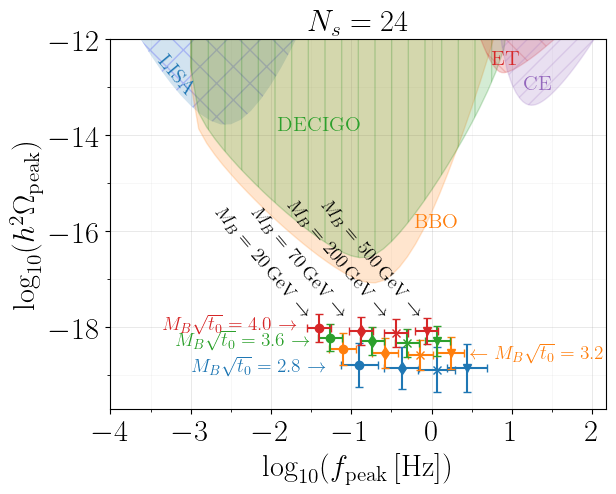

In [8]:
# N_s single-volume sensitivity plot on log10 LINEAR axes (x=log10 f, y=log10 h^2 Omega).
# Original fT_res_v2 Cell-12 layout: color=M_B\sqrt{t_0}, marker=M_B[GeV]; points+errorbars, no lines,
# no per-series legend; the log10-linear view is pixel-identical to the original log-log view so the
# EXACT Cell-12 arrow annotations + rotations are kept (positions just wrapped in np.log10).
LN10 = np.log(10.0)
lgf = np.log10(arr[:, 3])
lgO = np.log10(arr[:, 4])
elgf = np.sqrt((arr[:, 5] / (arr[:, 3] * LN10))**2 + np.loadtxt("sigma_hist_24c_v17_claude.dat")[:, 2]**2)  # stat (+) hist   # error propagated to log10(f)
elgO = np.sqrt((arr[:, 6] / (arr[:, 4] * LN10))**2 + np.loadtxt("sigma_hist_24c_v17_claude.dat")[:, 3]**2)  # stat (+) hist   # error propagated to log10(h^2 Omega)

plt.clf()
fig = plt.figure()
ax = plt.axes()

# barely-visible grid (drawn first, behind everything)
ax.set_axisbelow(True)
ax.grid(True, which='major', color='0.6', alpha=0.30, lw=0.5, zorder=0)
ax.grid(True, which='minor', color='0.8', alpha=0.25, lw=0.4, zorder=0)

# detector threshold bands: PLIS cols are ALREADY log10(f), log10(h^2 Omega) -> plot directly; fill up to 0
ax.fill_between(LISA[::500].T[0], LISA[::500].T[1], 0.0,
                color='C0', edgecolor='b', hatch='X', linewidth=0.0, alpha=0.2)
ax.fill_between(BBO[::400].T[0], BBO[::400].T[1], 0.0,
                color='C1', alpha=0.2)
ax.fill_between(DECIGO[::400].T[0], DECIGO[::400].T[1], 0.0,
                color='C2', edgecolor='g', hatch='|', alpha=0.2)
ax.fill_between(ET[0:160:2].T[0], ET[0:160:2].T[1], 0.0,
                color='C3', edgecolor='C3', hatch='\\', alpha=0.2)
ax.fill_between(CE[:400:5].T[0], CE[:400:5].T[1], 0.0,
                color='C4', edgecolor='C4', hatch='//', alpha=0.2)

# points: color = M_B\sqrt{t_0} (colors[im]), marker = M_B [GeV] (markers[i]); row = i*4 + im
for i in range(4):          # i = M_B [GeV] index (marker)
    for im in range(4):     # im = M_B\sqrt{t_0} index (color)
        r = i * 4 + im
        ax.errorbar(lgf[r], lgO[r], xerr=elgf[r], yerr=elgO[r],
                    ls='none', capsize=3, marker=markers[i], c=colors[im], zorder=3)

ax.set_xlim(-4.0, np.log10(150))
ax.set_ylim(np.log10(2e-20), -12.0)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
ax.set_xlabel("$\\log_{10}(f_{\\rm peak}\\,[{\\rm Hz}])$", fontsize=22)
ax.set_ylabel("$\\log_{10}(h^2\\Omega_{\\rm peak})$", fontsize=22)
ax.set_title("$N_s = " + str(NS) + "$", fontsize=22)

# --- exact annotations from fT_res_v2 Cell 12 (positions wrapped in log10; rotations unchanged) ---
ax.text(np.log10(0.00044), np.log10(9.0e-19), "$M_B\\sqrt{t_0}=4.0 \\rightarrow$", fontsize=14, color=colors[3])
ax.text(np.log10(0.00064), np.log10(4.e-19), "$M_B\\sqrt{t_0}=3.6 \\rightarrow$", fontsize=14, color=colors[2])
ax.text(np.log10(3.0), np.log10(2.2e-19), "$\\leftarrow M_B\\sqrt{t_0}=3.2$", fontsize=14, color=colors[1])
ax.text(np.log10(0.001), np.log10(1.2e-19), "$M_B\\sqrt{t_0}=2.8 \\rightarrow$", fontsize=14, color=colors[0])

ax.text(np.log10(0.0018), np.log10(1.6e-18), "$M_B=20 \\,{\\rm GeV} \\rightarrow$", fontsize=14, rotation=-50)
ax.text(np.log10(0.005), np.log10(1.6e-18), "$M_B=70 \\,{\\rm GeV} \\rightarrow$", fontsize=14, rotation=-50)
ax.text(np.log10(0.014), np.log10(1.6e-18), "$M_B=200 \\,{\\rm GeV} \\rightarrow$", fontsize=14, rotation=-50)
ax.text(np.log10(0.038), np.log10(1.6e-18), "$M_B=500 \\,{\\rm GeV} \\rightarrow$", fontsize=14, rotation=-50)

ax.text(np.log10(0.00035), np.log10(7.0e-14), "${\\rm LISA}$", fontsize=15, rotation=-50, color='C0')
ax.text(np.log10(0.6), np.log10(1.20e-16), "${\\rm BBO}$", fontsize=15, rotation=0, color='C1')
ax.text(np.log10(0.012), np.log10(125.0e-16), "${\\rm DECIGO}$", fontsize=15, rotation=0, color='C2')
ax.text(np.log10(5.5), np.log10(3.0e-13), "${\\rm ET}$", fontsize=15, rotation=0, color='C3')
ax.text(np.log10(14.0), np.log10(9.0e-14), "${\\rm CE}$", fontsize=15, rotation=0, color='C4')

plt.savefig("sensitivity_Ns" + str(NS) + "_c2only_stathist_claude.pdf", format='pdf', bbox_inches='tight')
plt.savefig("sensitivity_Ns" + str(NS) + "_c2only_stathist_claude.png", format='png', dpi=150, bbox_inches='tight')
plt.show()